1. Linear Regression (Single Variable)
2. Linear Regression (Multiple Variable)
3. Decision Tree Classifier
4. Logistic Regression
5. Support Vector Machine 
6. Random Forest 
7. k-Nearest Neighbours 
8. Naive Bayes 
9. k-Mean Clustering

# **1. Linear Regression (Single Variable)**

**Problem-1:** Linear Regression (Single variable)based prediction of car speed for given dataset and verify the model by comparing predicted value with the calculated value.

---



In [ ]:
#Inserting packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
#Load the dataset
df=pd.read_csv('car driving risk analysis.csv')
df.head()

,speed,risk
0,200,95
1,90,20
2,300,98
3,110,60
4,240,72


In [ ]:
df.shape

(15, 2)

In [ ]:
#Check the presence of null value 
df.isnull().any()

speed    False
risk     False
dtype: bool

In [ ]:
#sum of null value in the column
df.isnull().sum()

speed    0
risk     0
dtype: int64

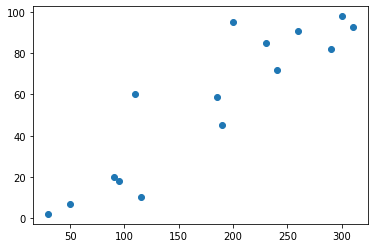

In [ ]:
#Dataset visualization
plt.scatter(df['speed'],df['risk'])

Text(0.5, 1.0, 'Car driving risk analysis')

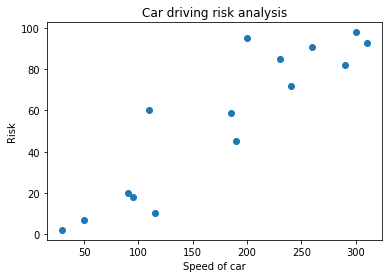

In [ ]:
plt.scatter(df['speed'],df['risk'])
plt.xlabel('Speed of car')
plt.ylabel('Risk')
plt.title('Car driving risk analysis')

Text(0.5, 1.0, 'Car driving risk analysis')

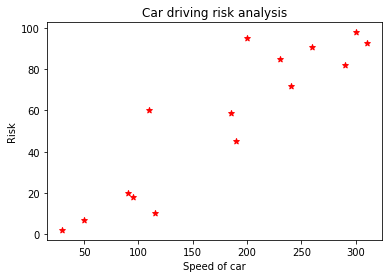

In [ ]:
plt.scatter(df['speed'],df['risk'],marker='*',color='red')
plt.xlabel('Speed of car')
plt.ylabel('Risk')
plt.title('Car driving risk analysis')

In [ ]:
#Feature Visualization
x=df[['speed']]
y=df['risk']

In [ ]:
x

,speed
0,200
1,90
2,300
3,110
4,240
5,115
6,50
7,230
8,190
9,260


In [ ]:
y

0     95
1     20
2     98
3     60
4     72
5     10
6      7
7     85
8     45
9     91
10    82
11    59
12    93
13    18
14     2
Name: risk, dtype: int64

In [ ]:
#Divide the dataset into test and train data
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=1)

In [ ]:
xtrain

,speed
4,240
1,90
13,95
0,200
14,30
9,260
8,190
12,310
11,185
5,115


In [ ]:
ytrain

4     72
1     20
13    18
0     95
14     2
9     91
8     45
12    93
11    59
5     10
Name: risk, dtype: int64

In [ ]:
xtest

,speed
3,110
7,230
6,50
2,300
10,290


In [ ]:
ytest

3     60
7     85
6      7
2     98
10    82
Name: risk, dtype: int64

In [ ]:
#Train the model
from sklearn.linear_model import LinearRegression
lr=LinearRegression() #Creating object lr
lr.fit(xtrain, ytrain) #train the model

LinearRegression()

In [ ]:
#Prediction
lr.predict(xtest)

array([26.93182066, 72.91851205,  3.93847496, 99.74408203, 95.91185775])

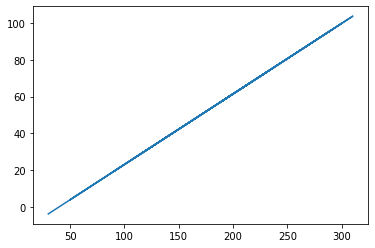

In [ ]:
#Draw best fit line
plt.plot(df.speed, lr.predict(df[['speed']]))

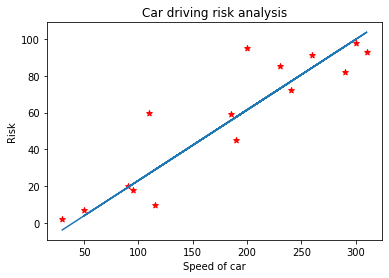

In [ ]:
plt.scatter(df['speed'],df['risk'],marker='*',color='red')
plt.xlabel('Speed of car')
plt.ylabel('Risk')
plt.title('Car driving risk analysis')
plt.plot(df.speed, lr.predict(df[['speed']]))

In [ ]:
#Predict the risk for the speed of 110
lr.predict([[110]])

/usr/local/lib/python3.8/dist-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([26.93182066])

In [ ]:
#y=mx+c
lr.coef_ #value of m

array([0.38322243])

In [ ]:
lr.intercept_ #value of c

-15.222646449220008

In [ ]:
#Calculate manually y=mx+c
#Then compare the calculated value with the predicted value 
y=0.38322243*110+-15.222646449220008
y

26.931820850779992

Predicted value and calculated value is same. 

# **2. Linear Regression (Multiple Variables)**

**Problem-2:** Linear regression (multiple variables) based car driving risk analysis for given dataset. 

---



In [ ]:
#Importing libraries 
import pandas as pd
import numpy as np
from sklearn import linear_model
#loading dataset
df=pd.read_csv('car driving risk analysis multiple.csv')
df.head()

,speed,car_age,experience,risk
0,200,15,5.0,85
1,90,17,13.0,20
2,165,12,4.0,93
3,110,20,NaN,60
4,140,5,3.0,82


In [ ]:
#View specific features
df.experience

0     5.0
1    13.0
2     4.0
3     NaN
4     3.0
5     8.0
Name: experience, dtype: float64

In [ ]:
#Calculate mean value to replace the NaN value 
df.experience.mean()

6.6

In [ ]:
#Or we can calculate median value to replace the NaN value 
df.experience.median()

5.0

In [ ]:
#Create a variable to put the median value for replacing the NaN value
PreprocessedData=df.experience.median()
PreprocessedData

5.0

The **fillna()** method replaces the NULL values with a specified value. The fillna() method returns a new DataFrame object unless the inplace parameter is set to True , in that case the fillna() method does the replacing in the original DataFrame instead.

In [ ]:
#replace the NaN value obtained in line 10
df.experience = df.experience.fillna(PreprocessedData)
df

,speed,car_age,experience,risk
0,200,15,5.0,85
1,90,17,13.0,20
2,165,12,4.0,93
3,110,20,5.0,60
4,140,5,3.0,82
5,115,2,8.0,10


In [ ]:
df.experience

0     5.0
1    13.0
2     4.0
3     5.0
4     3.0
5     8.0
Name: experience, dtype: float64

In [ ]:
lr=linear_model.LinearRegression() #Creat an object 
#Train the model
lr.fit(df[['speed','car_age','experience']],df.risk)

LinearRegression()

In [ ]:
#Predict the model
lr.predict([[160,10,5]]) #test the model (enclosed within double bracket)

/usr/local/lib/python3.8/dist-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([71.37146872])

In [ ]:
#Test the model manually
lr.coef_

array([ 0.33059217,  1.61053246, -6.20772074])

In [ ]:
lr.intercept_

33.41000091043588

In [ ]:
#calculate manually by putting the values obtained from the above
0.33059217*160+ 1.61053246*10+-6.20772074*5+33.41000091043589

71.3714690104359

**Problem-3:**  Profit prediction (regression task) using multiple linear regression model. 

---



In [ ]:
#Importing Libraries 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
#Load the dataset
df=pd.read_csv('online.csv')
df.head()

,Marketing Spend,Administration,Transport,Area,Profit
0,114523.61,136897.80,471784.10,Dhaka,192261.83
1,162597.70,151377.59,443898.53,Ctg,191792.06
2,153441.51,101145.55,407934.54,Rangpur,191050.39
3,144372.41,118671.85,383199.62,Dhaka,182901.99
4,142107.34,91391.77,366168.42,Rangpur,166187.94


In [ ]:
#Determine the size of dataset
df.shape

(50, 5)

In [ ]:
#Check the presence of null value
df.isnull().sum()

Marketing Spend    0
Administration     0
Transport          0
Area               0
Profit             0
dtype: int64

In [ ]:
#If missing
#missing=df.Administration.mean()
#df.Administration=df.Administration.filling(missing)

In [ ]:
#Separate input variables (Independent) and target variable (Dependent)
#Drop target variable to get features (input)
x=df.drop(['Profit'],axis=1) 
x

,Marketing Spend,Administration,Transport,Area
0,114523.61,136897.80,471784.10,Dhaka
1,162597.70,151377.59,443898.53,Ctg
2,153441.51,101145.55,407934.54,Rangpur
3,144372.41,118671.85,383199.62,Dhaka
4,142107.34,91391.77,366168.42,Rangpur
5,131876.90,99814.71,362861.36,Dhaka
6,134615.46,147198.87,127716.82,Ctg
7,130298.13,145530.06,323876.68,Rangpur
8,120542.52,148718.95,311613.29,Dhaka
9,123334.88,108679.17,304981.62,Ctg


In [ ]:
#Separate the target variable
y=df['Profit']
y

0     192261.83
1     191792.06
2     191050.39
3     182901.99
4     166187.94
5     156991.12
6     156122.51
7     155752.60
8     152211.77
9     149759.96
10    146121.95
11    144259.40
12    141585.52
13    134307.35
14    132602.65
15    129917.04
16    126992.93
17    125370.37
18    124266.90
19    122776.86
20    118474.03
21    111313.02
22    110352.25
23    108733.99
24    108552.04
25    107404.34
26    105733.54
27    105008.31
28    103282.38
29    101004.64
30     99937.59
31     97483.56
32     97427.84
33     96778.92
34     96712.80
35     96479.51
36     90708.19
37     89949.14
38     81229.06
39     81005.76
40     78239.91
41     77798.83
42     71498.49
43     69758.98
44     65200.33
45     64926.08
46     49490.75
47     42559.73
48     35673.41
49     14681.40
Name: Profit, dtype: float64

**What is drop first true in Get_dummies?**

This will cause get_dummies to create one dummy variable for every level of the input categorical variable. What is this? If you set drop_first = True , then it will drop the first category. So if you have K categories, it will only produce K – 1 dummy variables.

In [ ]:
#One hot encoding
#Converting the categorical column into numerical column 
city=pd.get_dummies(x['Area'],drop_first=True)
#if drop_first is true it removes the first column which 
#is created for the first unique value of a column.
city

,Dhaka,Rangpur
0,1,0
1,0,0
2,0,1
3,1,0
4,0,1
5,1,0
6,0,0
7,0,1
8,1,0
9,0,0


axis=1 (or axis='columns') is vertical axis. To take it further, if you use pandas method drop, to remove columns or rows, if you specify axis=1 you will be removing columns. If you specify axis=0 you will be removing rows from dataset. So if we have some pandas dataframe in variable df: df.

In [ ]:
#Drop the area column 
x=x.drop('Area',axis=1)
x

,Marketing Spend,Administration,Transport
0,114523.61,136897.80,471784.10
1,162597.70,151377.59,443898.53
2,153441.51,101145.55,407934.54
3,144372.41,118671.85,383199.62
4,142107.34,91391.77,366168.42
5,131876.90,99814.71,362861.36
6,134615.46,147198.87,127716.82
7,130298.13,145530.06,323876.68
8,120542.52,148718.95,311613.29
9,123334.88,108679.17,304981.62


In [ ]:
#Merge the input features x and encoded output
x=pd.concat([x,city],axis=1)
x

,Marketing Spend,Administration,Transport,Dhaka,Rangpur
0,114523.61,136897.80,471784.10,1,0
1,162597.70,151377.59,443898.53,0,0
2,153441.51,101145.55,407934.54,0,1
3,144372.41,118671.85,383199.62,1,0
4,142107.34,91391.77,366168.42,0,1
5,131876.90,99814.71,362861.36,1,0
6,134615.46,147198.87,127716.82,0,0
7,130298.13,145530.06,323876.68,0,1
8,120542.52,148718.95,311613.29,1,0
9,123334.88,108679.17,304981.62,0,0


In [ ]:
#Splitting dataset into training and test set 
#Importing library
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.25,random_state=0)

In [ ]:
#Visualize the training set (both input and target)
xtrain #input features

,Marketing Spend,Administration,Transport,Dhaka,Rangpur
34,46426.07,157693.92,210797.67,0,0
18,91749.16,114175.79,294919.57,0,1
7,130298.13,145530.06,323876.68,0,1
14,119943.24,156547.42,256512.92,0,1
45,1000.23,124153.04,1903.93,1,0
48,542.05,51743.15,0.00,1,0
29,65605.48,153032.06,107138.38,1,0
15,165349.20,122616.84,261776.23,1,0
30,61994.48,115641.28,91131.24,0,1
32,63408.86,129219.61,46085.25,0,0


In [ ]:
ytrain #target or label 

34     96712.80
18    124266.90
7     155752.60
14    132602.65
45     64926.08
48     35673.41
29    101004.64
15    129917.04
30     99937.59
32     97427.84
16    126992.93
42     71498.49
20    118474.03
43     69758.98
8     152211.77
13    134307.35
25    107404.34
5     156991.12
17    125370.37
40     78239.91
49     14681.40
1     191792.06
12    141585.52
37     89949.14
24    108552.04
6     156122.51
23    108733.99
36     90708.19
21    111313.02
19    122776.86
9     149759.96
39     81005.76
46     49490.75
3     182901.99
0     192261.83
47     42559.73
44     65200.33
Name: Profit, dtype: float64

In [ ]:
#Train the model
#Fitting multiple linear regression to the training set
from sklearn.linear_model import LinearRegression
reg=LinearRegression()
reg.fit(xtrain,ytrain)

LinearRegression()

In [ ]:
#Visualize the test data
xtest #input features as test set

,Marketing Spend,Administration,Transport,Dhaka,Rangpur
28,66051.52,182645.56,118148.20,0,1
11,100671.96,91790.61,249744.55,0,0
10,101913.08,110594.11,229160.95,0,1
41,27892.92,84710.77,164470.71,0,1
2,153441.51,101145.55,407934.54,0,1
27,72107.60,127864.55,353183.81,1,0
38,20229.59,65947.93,185265.10,1,0
31,61136.38,152701.92,88218.23,1,0
22,73994.56,122782.75,303319.26,0,1
4,142107.34,91391.77,366168.42,0,1


In [ ]:
ytest #original target or label

28    103282.38
11    144259.40
10    146121.95
41     77798.83
2     191050.39
27    105008.31
38     81229.06
31     97483.56
22    110352.25
4     166187.94
33     96778.92
35     96479.51
26    105733.54
Name: Profit, dtype: float64

In [ ]:
#Prediction (predicted data is pred here)
pred=reg.predict(xtest)
pred

array([103501.0825284 , 128011.28068627, 126695.43891127,  70573.91718775,
       173381.96874259, 124238.07860872,  69298.09250304,  98399.41936876,
       116419.1480864 , 161430.98134847,  94740.73303076,  89920.22800514,
       105956.86065332])

In [ ]:
#Accuracy calculation
reg.score(xtrain,ytrain)

0.8974559535833022

In [ ]:
#R-Squared Value/ Correlation Coefficient 
from sklearn.metrics import r2_score
score=r2_score(ytest,pred)
score

0.884097862392347

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import explained_variance_score, mean_squared_error

In [ ]:
gbr=GradientBoostingRegressor(random_state=0)
gbr.fit(xtrain,ytrain)

GradientBoostingRegressor(random_state=0)

In [ ]:
gbr.score(xtest,ytest)

0.8722240251407006

In [ ]:
nnr=MLPRegressor(
    hidden_layer_sizes=(30,30,30,30),
    activation="relu",
    random_state=0
)
nnr.fit(xtrain,ytrain)

MLPRegressor(hidden_layer_sizes=(30, 30, 30, 30), random_state=0)

In [ ]:
nnr.score(xtest,ytest)

0.655701953530063

In [ ]:
#Hybrid Machine Learning
from mlxtend.regressor import StackingRegressor
from sklearn.svm import SVR
hybrid=(reg,gbr,nnr)
svr_hybrid=SVR(kernel='rbf')
stregr=StackingRegressor(
    regressors=hybrid,
    meta_regressor=svr_hybrid
)
stregr.fit(xtrain,ytrain)

StackingRegressor(meta_regressor=SVR(),
                  regressors=(LinearRegression(),
                              GradientBoostingRegressor(random_state=0),
                              MLPRegressor(hidden_layer_sizes=(30, 30, 30, 30),
                                           random_state=0)))

In [ ]:
stregr.score(xtest,ytest)

-0.06390301413648047

# **3. Decision Tree**

**Problem-4:** Classify male or female based on a dataset containing height, weight and shoe size based on decision tree classifier. 

---



In [ ]:
#Importing libraries
import pandas as pd
from sklearn import tree
#Read the dataset
df=pd.read_csv('male female.csv')
df.head()

,height,weight,shoe size,gender
0,181,80,44,male
1,177,70,43,female
2,160,60,38,female
3,154,54,37,female
4,166,65,40,male


The **iloc()** function in python is one of the functions defined in the Pandas module that helps us to select a specific row or column from the data set. Using the iloc() function in python, we can easily retrieve any particular value from a row or column using index values.

df.iloc[:, 2] selects the second column but df.iloc[:, :2] or explicitly df.iloc[:, 0:2] selects the columns until (excluding) the second column. It's the same as Python's slices. When you use a negative index, nothing changes. If you say df.iloc[:, -1] it means the last column, but df.iloc[:, :-1] means until the last column. 

In [ ]:
#Separate independent or input variables
x=df.iloc[:,:-1]
x

,height,weight,shoe size
0,181,80,44
1,177,70,43
2,160,60,38
3,154,54,37
4,166,65,40
5,190,90,47
6,175,64,39
7,171,75,42
8,185,85,43
9,169,71,42


In [ ]:
#Separate dependent or output variable
y=df.iloc[:,3]
y

0      male
1    female
2    female
3    female
4      male
5      male
6      male
7    female
8    female
9      male
Name: gender, dtype: object

In [ ]:
#Develop classifier
classify_=tree.DecisionTreeClassifier()
#Train the model
classify_.fit(x,y)

DecisionTreeClassifier()

In [ ]:
#Prediction
pred=classify_.predict([[190,70,43]])
pred

/usr/local/lib/python3.8/dist-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['female'], dtype=object)

In [ ]:
pred=classify_.predict([[190,80,45]])
pred

/usr/local/lib/python3.8/dist-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['male'], dtype=object)

**Problem-5:** Classify whether a product in the shop will sell or not based on decision tree classifier. 

---



In [ ]:
#Import libraries
import pandas as pd
#Read the dataset
df=pd.read_csv('shop data.csv')
df.head()

,age,income,gender,m_status,buys
0,<25,high,male,single,no
1,<25,high,male,married,no
2,25-35,high,male,single,yes
3,>35,medium,male,single,yes
4,>35,low,female,single,yes


In [ ]:
#Separate input features 
x=df.iloc[:,:-1]
x

,age,income,gender,m_status
0,<25,high,male,single
1,<25,high,male,married
2,25-35,high,male,single
3,>35,medium,male,single
4,>35,low,female,single
5,>35,low,female,single
6,25-35,low,female,married
7,<25,medium,male,married
8,<25,low,female,single
9,>35,medium,female,married


In [ ]:
#Separate target variable 
y=df.iloc[:,4]
y

0      no
1      no
2     yes
3     yes
4     yes
5      no
6     yes
7      no
8     yes
9     yes
10    yes
11    yes
12    yes
13     no
14     no
Name: buys, dtype: object

In [ ]:
#Data Preprocessing
#Import libraries for label encoding 
from sklearn.preprocessing import LabelEncoder
Le_x=LabelEncoder() #creating object
#Transform into numerical number
x=x.apply(LabelEncoder().fit_transform)
x

,age,income,gender,m_status
0,1,0,1,1
1,1,0,1,0
2,0,0,1,1
3,2,2,1,1
4,2,1,0,1
5,2,1,0,1
6,0,1,0,0
7,1,2,1,0
8,1,1,0,1
9,2,2,0,0


In [ ]:
#Develop classifier
from sklearn.tree import DecisionTreeClassifier
import numpy as np #Needed to convert it into array
dtf=DecisionTreeClassifier() #Creating object
#Train the model
dtf.fit(x.iloc[:,0:4],y)

DecisionTreeClassifier()

In [ ]:
#Test the model
xinput=np.array([1,1,0,0])
ypred=dtf.predict([xinput])
ypred

/usr/local/lib/python3.8/dist-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['yes'], dtype=object)

# **4. Logistic Regression**

**Problem-6:** Classify whether a person is married or not based on binary logistic regression. 

---



The only reason %matplotlib inline is used is to render any matplotlib diagrams even if the plt. show() function is not called. However, even if %matplotlib inline is not used, Jupyter will still display the Matplotlib diagram as an object, with something like matplotlib. lines.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
#Load dataset
df=pd.read_csv('marital status.csv')
df.head()

,age,status
0,21,0.0
1,33,1.0
2,24,0.0
3,28,1.0
4,17,0.0


In [ ]:
#Check the presence of null value
df.isnull().sum()

age       0
status    1
dtype: int64

In [ ]:
#Replace the null position with maximum number of 1 or 0
#So we have to find the median
#If we deal with age, then we will determine the mean
handle=df['status'].median()
handle

0.0

In [ ]:
#Data preprocessing 
df.status=df.status.fillna(handle)
df

,age,status
0,21,0.0
1,33,1.0
2,24,0.0
3,28,1.0
4,17,0.0
5,33,1.0
6,23,0.0
7,30,0.0
8,29,1.0
9,22,0.0


In [ ]:
#Count the number of zero and one 
#Married: 9 and Unmarried: 11
df['status'].value_counts()

0.0    11
1.0     9
Name: status, dtype: int64

In [ ]:
#Separate independent variable
x=df[['age']]
x

,age
0,21
1,33
2,24
3,28
4,17
5,33
6,23
7,30
8,29
9,22


In [ ]:
#Separate dependent variable
y=df['status']
y

0     0.0
1     1.0
2     0.0
3     1.0
4     0.0
5     1.0
6     0.0
7     0.0
8     1.0
9     0.0
10    1.0
11    0.0
12    0.0
13    0.0
14    1.0
15    1.0
16    0.0
17    0.0
18    1.0
19    1.0
Name: status, dtype: float64

In [ ]:
#split train and test data
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=1)

In [ ]:
#training data
xtrain

,age
4,17
17,18
7,30
1,33
13,24
0,21
19,25
18,26
9,22
15,29


In [ ]:
ytrain

4     0.0
17    0.0
7     0.0
1     1.0
13    0.0
0     0.0
19    1.0
18    1.0
9     0.0
15    1.0
8     1.0
12    0.0
11    0.0
5     1.0
Name: status, dtype: float64

In [ ]:
#Importing Logistic Regression
from sklearn.linear_model import LogisticRegression
model=LogisticRegression() #creating object
#Train the model
model.fit(xtrain,ytrain)

LogisticRegression()

In [ ]:
#Test data set
xtest

,age
3,28
16,16
6,23
10,26
2,24
14,34


In [ ]:
#Original target
ytest

3     1.0
16    0.0
6     0.0
10    1.0
2     0.0
14    1.0
Name: status, dtype: float64

In [ ]:
#Test the model
model.predict(xtest) #Logistic output

array([1., 0., 0., 0., 0., 1.])

In [ ]:
#Accuracy measurement 
model.score(xtest,ytest)

0.8333333333333334

In [ ]:
#Signmoidal output
model.predict_proba(xtest)
#first one is for no value, second one is for yes value

array([[0.28697051, 0.71302949],
       [0.9902967 , 0.0097033 ],
       [0.80161052, 0.19838948],
       [0.50311753, 0.49688247],
       [0.71810555, 0.28189445],
       [0.02465085, 0.97534915]])

**Problem-7:** Implement customer churn prediction using logistic regression model.  

---



Seaborn is a library that uses Matplotlib underneath to plot graphs. It will be used to visualize random distributions.

In [96]:
#Importing basic libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#Read dataset
df=pd.read_csv('Customer-Churn-Prediction.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [97]:
#Determine the size of dataset
df.shape

(7043, 21)

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


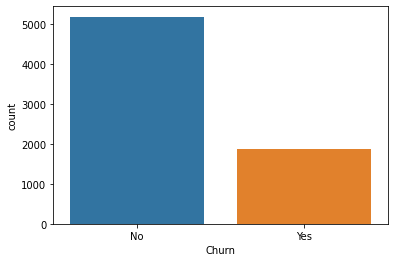

In [98]:
#Show the churn 
sns.countplot(df['Churn'])

In [99]:
#Count the churn
df['Churn'].value_counts()

No     5174
Yes    1869
Name: Churn, dtype: int64

In [101]:
#Expressed the Churned and not churned in percentage 
Churned=df[df.Churn=='Yes'].shape[0]
Retained=df[df.Churn=='No'].shape[0]
#Churned in %
Ch_per=((Churned/(Churned+Retained))*100)
Ch_per

26.536987079369588

In [102]:
#Not churned in %
Re_per=((Retained/(Churned+Retained))*100)
Re_per

73.4630129206304

In [103]:
#Check the presence of null value in dataset
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [104]:
df.isnull().values.any()

False

In [105]:
#Show the details of dataset
df.describe

<bound method NDFrame.describe of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DS

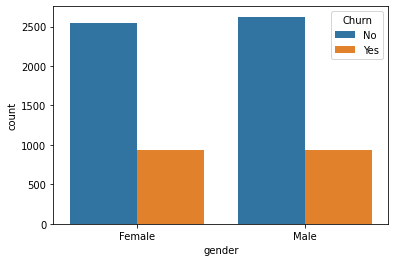

In [106]:
#Show the churn w.r.t gender 
sns.countplot(x='gender',hue='Churn',data=df)

In [107]:
#Count the churn w.r.t gender 
df['gender'].value_counts()

Male      3555
Female    3488
Name: gender, dtype: int64

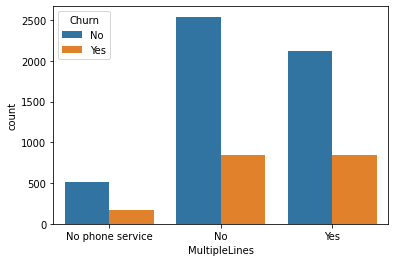

In [108]:
#Show the churn w.r.t MultipleLines 
sns.countplot(x='MultipleLines',hue='Churn',data=df)

In [109]:
#Count the churn w.r.t MultipleLines
df['MultipleLines'].value_counts()

No                  3390
Yes                 2971
No phone service     682
Name: MultipleLines, dtype: int64

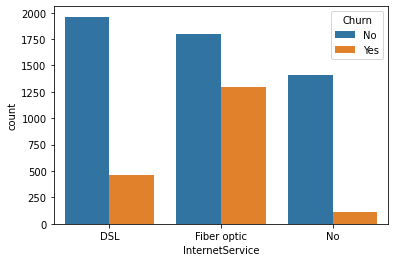

In [110]:
#Show the churn w.r.t InternetService
sns.countplot(x='InternetService',hue='Churn',data=df)

In [111]:
#Count the churn w.r.t InternetService
df['InternetService'].value_counts()

Fiber optic    3096
DSL            2421
No             1526
Name: InternetService, dtype: int64

In [112]:
#Preprocessing
#Drop the Customer ID from dataset
df=df.drop('customerID',axis=1)
#Again see the size of dataset
df.shape

(7043, 20)

In [113]:
#Label Encoding 
#Convert the categorical value into numerical value
#Importing library for label encoding 
from sklearn.preprocessing import LabelEncoder
#Implement Label Encoding 
for column in df.columns:
  if df[column].dtype==np.number:
    continue
  df[column]=LabelEncoder().fit_transform(df[column])
df

<ipython-input-113-b8676d4ba168>:7: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  if df[column].dtype==np.number:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,2505,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1466,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,157,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1400,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,925,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1597,0
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,5698,0
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,2994,0
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,2660,1


In [114]:
#Separate the input features from dataset
#Drop the Churn and assigned it as feature 
x=df.drop('Churn',axis=1)
x

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,2505
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1466
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,157
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1400
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1597
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,5698
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,2994
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,2660


In [115]:
#Separate the target or output 
y=df['Churn']
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

In [116]:
#Feature scaling 
#Standardisation scaling 
#Importing library for Standardisation scaling 
from sklearn.preprocessing import StandardScaler
#Creat an object
feature_x=StandardScaler().fit_transform(x)
feature_x

array([[-1.00955867, -0.44014635,  1.03453023, ...,  0.39855772,
        -1.16032292, -0.39860759],
       [ 0.99053183, -0.44014635, -0.96662231, ...,  1.33486261,
        -0.25962894, -0.94876238],
       [ 0.99053183, -0.44014635, -0.96662231, ...,  1.33486261,
        -0.36266036, -1.64188328],
       ...,
       [-1.00955867, -0.44014635,  1.03453023, ...,  0.39855772,
        -1.1686319 , -0.13968008],
       [ 0.99053183,  2.27197156,  1.03453023, ...,  1.33486261,
         0.32033821, -0.31653445],
       [ 0.99053183, -0.44014635, -0.96662231, ..., -1.47405205,
         1.35896134,  1.13801338]])

In [117]:
#Importing library for splitting dataset
from sklearn.model_selection import train_test_split
#Split the dataset into train and test set
xtrain,xtest,ytrain,ytest=train_test_split(feature_x,y,test_size=0.25,random_state=42)

In [118]:
#Show the train data set
xtrain

array([[ 0.99053183, -0.44014635, -0.96662231, ...,  0.39855772,
        -1.31154644, -0.58499305],
       [-1.00955867, -0.44014635, -0.96662231, ...,  0.39855772,
         0.34526517,  0.60268471],
       [-1.00955867, -0.44014635, -0.96662231, ..., -1.47405205,
        -1.48603513,  1.5637347 ],
       ...,
       [ 0.99053183, -0.44014635,  1.03453023, ...,  0.39855772,
        -1.44947559, -0.31706396],
       [ 0.99053183,  2.27197156, -0.96662231, ...,  0.39855772,
         1.15289851, -1.5290989 ],
       [ 0.99053183, -0.44014635, -0.96662231, ..., -0.53774716,
        -1.49434411,  0.33475562]])

In [119]:
ytrain

6607    1
2598    0
2345    0
4093    0
693     1
       ..
3772    1
5191    0
5226    0
5390    1
860     0
Name: Churn, Length: 5282, dtype: int64

In [120]:
#Importing library for logistic regression model
from sklearn.linear_model import LogisticRegression
#Creat an object
lr=LogisticRegression()
#Train the model
lr.fit(xtrain,ytrain)
#Test the model
pred=lr.predict(xtest)
pred

array([1, 0, 0, ..., 0, 1, 0])

In [121]:
#Importing library for accuracy score
from sklearn.metrics import accuracy_score
#Determine the accuracy 
accuracy_score(ytest,pred)

0.8103350369108461

In [122]:
#Confusion Matrix
#Importing library for confusion matrix
from sklearn.metrics import confusion_matrix
#Determine confusion matrix
confusion_matrix(ytest,pred)

array([[1163,  119],
       [ 215,  264]])

In [123]:
#Classification report
from sklearn.metrics import classification_report
print(classification_report(ytest,pred))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1282
           1       0.69      0.55      0.61       479

    accuracy                           0.81      1761
   macro avg       0.77      0.73      0.74      1761
weighted avg       0.80      0.81      0.80      1761



# **5. Support Vector Machine**

**Problem-8:** Classify whether a person will make a payment or not of credit card based on support vector machine. 

---



In [124]:
#Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
#Load the dataset
df=pd.read_csv('credit card taiwan svm algorithm.csv')
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24.0,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26.0,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,NaN,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,NaN,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2018.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57.0,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [126]:
#Determine the shape of dataset
df.shape

(30000, 25)

In [3]:
#check the presence of null value
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           2
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

In [4]:
#handling the null value
handle=df.AGE.mean()
handle

35.48549903326889

In [5]:
#Replace the null value with mean value
df.AGE=df.AGE.fillna(handle)

In [6]:
#Recheck the presence of null value
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

In [7]:
#Recheck the dataset
df

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24.000000,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26.000000,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,35.485499,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,35.485499,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2018.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57.000000,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,1,3,1,39.000000,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,1,3,2,43.000000,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,1,2,2,37.000000,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,1,3,1,41.000000,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


In [8]:
#Separate input features or independent variables
x=df.drop(['default.payment.next.month'],axis=1)
x

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,1,20000.0,2,2,1,24.000000,2,2,-1,-1,...,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0
1,2,120000.0,2,2,2,26.000000,-1,2,0,0,...,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0
2,3,90000.0,2,2,2,35.485499,0,0,0,0,...,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0
3,4,50000.0,2,2,1,35.485499,0,0,0,0,...,49291.0,28314.0,28959.0,29547.0,2000.0,2018.0,1200.0,1100.0,1069.0,1000.0
4,5,50000.0,1,2,1,57.000000,-1,0,-1,0,...,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,1,3,1,39.000000,0,0,0,0,...,208365.0,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0
29996,29997,150000.0,1,3,2,43.000000,-1,-1,-1,-1,...,3502.0,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0
29997,29998,30000.0,1,2,2,37.000000,4,3,2,-1,...,2758.0,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0
29998,29999,80000.0,1,3,1,41.000000,1,-1,0,0,...,76304.0,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0


In [9]:
#Separate dependent variable or taget output
y=df['default.payment.next.month']
y

0        1
1        1
2        0
3        0
4        0
        ..
29995    0
29996    0
29997    1
29998    1
29999    1
Name: default.payment.next.month, Length: 30000, dtype: int64

In [10]:
#Importing libraries for splitting train test data
from sklearn.model_selection import train_test_split
#Split train and test data
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.25,random_state=1)

In [11]:
#Show the training data
xtrain

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
26340,26341,150000.0,2,1,2,26.0,0,0,2,0,...,63156.0,57147.0,53383.0,48556.0,4850.0,2000.0,2000.0,2000.0,2000.0,1500.0
3877,3878,50000.0,2,2,2,23.0,0,0,0,0,...,42162.0,6765.0,19286.0,9558.0,2000.0,2102.0,255.0,3000.0,191.0,0.0
27081,27082,80000.0,1,2,2,31.0,0,0,0,0,...,72368.0,77505.0,78845.0,74182.0,3000.0,3500.0,7000.0,3100.0,3000.0,3000.0
5440,5441,120000.0,2,2,2,39.0,0,0,2,0,...,24372.0,24670.0,25617.0,26535.0,2400.0,1000.0,1000.0,1500.0,1500.0,1500.0
22164,22165,150000.0,2,1,3,30.0,1,-1,2,-1,...,6527.0,2168.0,-7.0,1373.0,0.0,8589.0,2500.0,0.0,1380.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17289,17290,170000.0,2,3,1,40.0,1,2,0,0,...,20619.0,19520.0,5200.0,0.0,0.0,2000.0,1136.0,1000.0,0.0,36679.0
5192,5193,330000.0,2,1,1,41.0,-1,-1,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12172,12173,50000.0,1,2,2,22.0,0,0,0,0,...,35458.0,19778.0,19929.0,19790.0,1707.0,1321.0,687.0,705.0,811.0,874.0
235,236,80000.0,1,1,2,35.0,-1,-1,-1,-1,...,6848.0,1719.0,1378.0,19942.0,3983.0,6853.0,1719.0,1378.0,19942.0,2418.0


In [12]:
ytrain

26340    0
3877     0
27081    0
5440     0
22164    0
        ..
17289    1
5192     0
12172    0
235      0
29733    0
Name: default.payment.next.month, Length: 22500, dtype: int64

In [13]:
#Importing libraries for SVM algorithm
#Develop SVM algorithm
from sklearn.svm import SVC
model=SVC(gamma='auto')
#Train the model
model.fit(xtrain,ytrain)

SVC(gamma='auto')

In [14]:
#Show the test data set
xtest

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
10747,10748,310000.0,1,3,1,32.0,0,0,0,0,...,110375.0,84373.0,57779.0,14163.0,8295.0,6000.0,4000.0,3000.0,1000.0,2000.0
12573,12574,10000.0,2,3,1,49.0,-1,-1,-2,-1,...,-748.0,1690.0,1138.0,930.0,0.0,0.0,2828.0,0.0,182.0,0.0
29676,29677,50000.0,1,2,1,28.0,-1,-1,-1,0,...,46257.0,45975.0,1300.0,43987.0,0.0,46257.0,2200.0,1300.0,43987.0,1386.0
8856,8857,80000.0,2,3,1,52.0,2,2,3,3,...,40101.0,40748.0,39816.0,40607.0,3700.0,1600.0,1600.0,0.0,1600.0,1600.0
21098,21099,270000.0,1,1,2,34.0,1,2,0,0,...,20924.0,22448.0,15490.0,17343.0,0.0,4000.0,2000.0,0.0,2000.0,2000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29317,29318,30000.0,1,3,2,26.0,0,0,0,0,...,25791.0,18972.0,28051.0,20782.0,2000.0,2000.0,1600.0,10000.0,2140.0,0.0
18629,18630,50000.0,2,1,2,26.0,0,0,0,0,...,18911.0,20090.0,20334.0,20856.0,1600.0,1700.0,1800.0,875.0,1000.0,4700.0
15329,15330,390000.0,2,1,2,33.0,-2,-2,-2,-2,...,0.0,0.0,1560.0,4386.0,1017.0,0.0,0.0,1560.0,4386.0,12000.0
14587,14588,130000.0,1,3,3,40.0,2,0,0,0,...,84822.0,85970.0,86644.0,87576.0,3515.0,3107.0,5003.0,3203.0,3456.0,4000.0


In [15]:
ytest

10747    0
12573    1
29676    0
8856     1
21098    0
        ..
29317    0
18629    0
15329    0
14587    0
15011    0
Name: default.payment.next.month, Length: 7500, dtype: int64

In [16]:
#Accuracy calculation for SVM algorithm
model.score(xtest,ytest)

0.7776

In [17]:
#Check the performance for Random Forest Algorithm
from sklearn.ensemble import RandomForestClassifier
rfc=RandomForestClassifier()
rfc.fit(xtrain,ytrain)
##Accuracy calculation for Random Forest algorithm
rfc.score(xtest,ytest)

0.8149333333333333

In [18]:
#Check the performance for Decision Tree Algorithm
from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier()
dtc.fit(xtrain,ytrain) 
##Accuracy calculation for Decision Tree algorithm
dtc.score(xtest,ytest) 

0.7257333333333333

# **6. Random Forest**

**Problem-9:** Classify whether a person has a heart disease or not based on random forest algorithm. 

---



In [19]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
#Load the dataset
df=pd.read_csv('cardio_train.csv')
df

,id;age;gender;height;weight;ap_hi;ap_lo;cholesterol;gluc;smoke;alco;active;cardio
0,0;18393;2;168;62.0;110;80;1;1;0;0;1;0
1,1;20228;1;156;85.0;140;90;3;1;0;0;1;1
2,2;18857;1;165;64.0;130;70;3;1;0;0;0;1
3,3;17623;2;169;82.0;150;100;1;1;0;0;1;1
4,4;17474;1;156;56.0;100;60;1;1;0;0;0;0
...,...
69995,99993;19240;2;168;76.0;120;80;1;1;1;0;1;0
69996,99995;22601;1;158;126.0;140;90;2;2;0;0;1;1
69997,99996;19066;2;183;105.0;180;90;3;1;0;1;0;1
69998,99998;22431;1;163;72.0;135;80;1;2;0;0;0;1


In [22]:
#Load the dataset
df=pd.read_csv('cardio_train.csv',sep=';')
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [23]:
#Dataset size determination
df.shape

(70000, 13)

In [24]:
#Count the number of cardio cases among dataset
df['cardio'].value_counts()

0    35021
1    34979
Name: cardio, dtype: int64

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


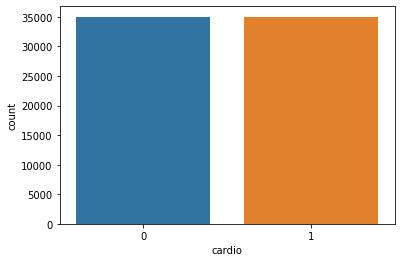

In [25]:
#Drawing graph of the number of cardio cases among dataset
sns.countplot(df['cardio'])

In [26]:
#Check the presence of null value 
df.isnull().values.any()

False

In [27]:
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

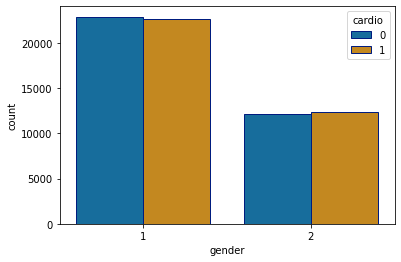

In [28]:
#Visualize the cardio data based on gender
sns.countplot(x='gender',hue='cardio',data=df,palette='colorblind',edgecolor=sns.color_palette('dark',n_colors=1))

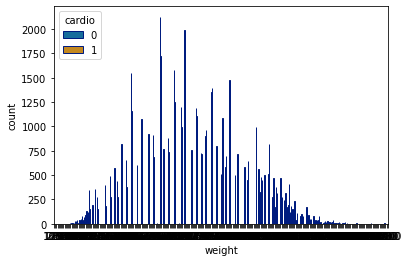

In [29]:
#Visualize the cardio data based on weight
sns.countplot(x='weight',hue='cardio',data=df,palette='colorblind',edgecolor=sns.color_palette('dark',n_colors=1))

In [30]:
#Converting the age in days to year
df['yr']=df['age']/365
df['yr']

0        50.391781
1        55.419178
2        51.663014
3        48.282192
4        47.873973
           ...    
69995    52.712329
69996    61.920548
69997    52.235616
69998    61.454795
69999    56.273973
Name: yr, Length: 70000, dtype: float64

In [31]:
df['yr']=(df['age']/365).round(0)
df['yr']

0        50.0
1        55.0
2        52.0
3        48.0
4        48.0
         ... 
69995    53.0
69996    62.0
69997    52.0
69998    61.0
69999    56.0
Name: yr, Length: 70000, dtype: float64

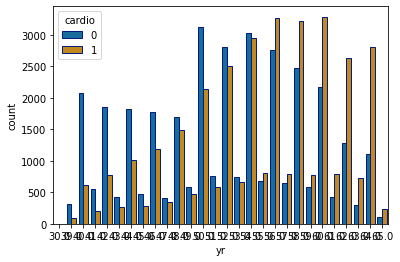

In [32]:
#Visualize the cardio data based on age in year
sns.countplot(x='yr',hue='cardio',data=df,palette='colorblind',edgecolor=sns.color_palette('dark',n_colors=1))

In [33]:
#Get detail information about the dataset
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,yr
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700,53.338686
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003,6.765294
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,30.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,54.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,58.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,65.000000


In [34]:
#Determine the correlation coefficient 
df.corr()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,yr
id,1.000000,0.003457,0.003502,-0.003038,-0.001830,0.003356,-0.002529,0.006106,0.002467,-0.003699,0.001210,0.003755,0.003799,0.003050
age,0.003457,1.000000,-0.022811,-0.081515,0.053684,0.020764,0.017647,0.154424,0.098703,-0.047633,-0.029723,-0.009927,0.238159,0.999090
gender,0.003502,-0.022811,1.000000,0.499033,0.155406,0.006005,0.015254,-0.035821,-0.020491,0.338135,0.170966,0.005866,0.008109,-0.023017
height,-0.003038,-0.081515,0.499033,1.000000,0.290968,0.005488,0.006150,-0.050226,-0.018595,0.187989,0.094419,-0.006570,-0.010821,-0.081456
weight,-0.001830,0.053684,0.155406,0.290968,1.000000,0.030702,0.043710,0.141768,0.106857,0.067780,0.067113,-0.016867,0.181660,0.053661
ap_hi,0.003356,0.020764,0.006005,0.005488,0.030702,1.000000,0.016086,0.023778,0.011841,-0.000922,0.001408,-0.000033,0.054475,0.020793
ap_lo,-0.002529,0.017647,0.015254,0.006150,0.043710,0.016086,1.000000,0.024019,0.010806,0.005186,0.010601,0.004780,0.065719,0.017754
cholesterol,0.006106,0.154424,-0.035821,-0.050226,0.141768,0.023778,0.024019,1.000000,0.451578,0.010354,0.035760,0.009911,0.221147,0.154386
gluc,0.002467,0.098703,-0.020491,-0.018595,0.106857,0.011841,0.010806,0.451578,1.000000,-0.004756,0.011246,-0.006770,0.089307,0.098596
smoke,-0.003699,-0.047633,0.338135,0.187989,0.067780,-0.000922,0.005186,0.010354,-0.004756,1.000000,0.340094,0.025858,-0.015486,-0.047884


In [35]:
#Drop the id from the dataset
df=df.drop(['id'],axis=1)
#Separate the input features or independent variables 
x=df.iloc[:,:-1]
#Separate the target data or dependent variables
y=df.iloc[:,11]

In [36]:
x

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [37]:
y

0        0
1        1
2        1
3        1
4        0
        ..
69995    0
69996    1
69997    1
69998    1
69999    0
Name: cardio, Length: 70000, dtype: int64

In [38]:
#Splitting the dataset into training and test dataset
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.30, random_state=1)

In [39]:
#Visualize the training dataset
xtrain

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
23561,16136,2,169,71.0,100,80,1,1,1,0,1,0
34858,14615,1,158,69.0,140,80,2,1,0,0,1,1
54953,20507,1,164,65.0,120,80,1,1,0,0,1,0
59230,16720,1,153,53.0,100,60,1,1,0,0,1,0
1730,21050,1,159,71.0,140,90,1,1,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
49100,21289,2,175,78.0,120,80,1,1,0,0,1,1
20609,19116,1,164,68.0,120,80,1,1,0,0,0,0
21440,18049,2,178,82.0,120,80,1,1,0,0,1,0
50057,21957,1,169,77.0,120,80,1,1,0,0,0,1


In [40]:
ytrain

23561    0
34858    1
54953    0
59230    0
1730     1
        ..
49100    1
20609    0
21440    0
50057    1
5192     1
Name: cardio, Length: 49000, dtype: int64

In [41]:
#Importing libraries for Random Forest Algorithm
from sklearn.ensemble import RandomForestClassifier
rfc=RandomForestClassifier(n_estimators=100)
#Train the model
rfc.fit(xtrain,ytrain)

RandomForestClassifier()

In [42]:
#Accuracy calculation of Random Forest Algorithm
rfc.score(xtest,ytest)

1.0

In [44]:
#Importing libraries for Decision Tree Algorithm
from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier()
#Train the model
dtc.fit(xtrain,ytrain)
#Accuracy calculation of Decision Tree Algorithm
dtc.score(xtest,ytest)

1.0

In [45]:
#Importing libraries for Support Vector Machine Algorithm
from sklearn.svm import SVC
svem=SVC(gamma='auto')
#Train the model
svem.fit(xtrain,ytrain)
#Accuracy calculation of Support Vector Machine Algorithm
svem.score(xtest,ytest)

0.5863333333333334

# **7. k-Nearest Neighbours**

**Problem-10:** Predict the weight of a person based on age and height using k-neighbors’ algorithm. 

---



In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
df=pd.read_csv('knn weight.csv')
df

,age,height,weight
0,45,5.00,77
1,26,5.11,47
2,30,5.60,55
3,34,5.90,59
4,40,4.80,72
5,36,5.80,60
6,19,5.30,40
7,28,5.80,60
8,23,5.50,45
9,32,5.60,58


In [47]:
x=df.iloc[:,:-1]
x

,age,height
0,45,5.00
1,26,5.11
2,30,5.60
3,34,5.90
4,40,4.80
5,36,5.80
6,19,5.30
7,28,5.80
8,23,5.50
9,32,5.60


In [48]:
y=df.iloc[:,2]
y

0    77
1    47
2    55
3    59
4    72
5    60
6    40
7    60
8    45
9    58
Name: weight, dtype: int64

In [49]:
df.isnull().sum()

age       0
height    0
weight    0
dtype: int64

In [50]:
df.shape

(10, 3)

In [51]:
from sklearn.neighbors import KNeighborsRegressor
model=KNeighborsRegressor(n_neighbors=5)
model.fit(x,y)
pred=model.predict(x)
pred

array([65.2, 53. , 55.8, 58.4, 65.2, 60.8, 49.4, 53. , 49.4, 58.4])

In [52]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y,pred)

37.999999999999986

**Problem-11:** To predict whether the play will be performed or not based on weather and temperature data assigned manually. 

In [53]:
#Assigning features and label variables
#First features
weather=['sunny','sunny','overcast','rainy','rainy''rainy','overcast','sunny','sunny','rainy','sunny','overcast','overcast','rainy']
#Second feature
temp=['hot','hot','hot','mild','cool','cool','cool','mild','cool','mild','mild','mild','hot','mild']
#Label or target variable
play=['no','no','yes','yes','yes','no','yes','no','yes','yes','yes','yes','yes']

In [54]:
#Importing label encoding
from sklearn import preprocessing
#creating label encoder
le=preprocessing.LabelEncoder()
#Converting string labels into numbers
weather_encoded=le.fit_transform(weather)
weather_encoded

array([3, 3, 0, 1, 2, 0, 3, 3, 1, 3, 0, 0, 1])

In [55]:
temp_encoded=le.fit_transform(temp)
temp_encoded

array([1, 1, 1, 2, 0, 0, 0, 2, 0, 2, 2, 2, 1, 2])

In [56]:
play_encoded=le.fit_transform(play)
play_encoded

array([0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1])

In [57]:
#Combining weather and temp into single list of tuples
feature=list(zip(weather_encoded,temp_encoded))
feature

[(3, 1),
 (3, 1),
 (0, 1),
 (1, 2),
 (2, 0),
 (0, 0),
 (3, 0),
 (3, 2),
 (1, 0),
 (3, 2),
 (0, 2),
 (0, 2),
 (1, 1)]

In [58]:
#Importing library for KNN algorithm
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=3)
#Train the model
model.fit(feature,play)

KNeighborsClassifier(n_neighbors=3)

In [59]:
#Predict Output
#0 for overcast and 2 for mild
pred=model.predict([[0,2]])
pred

array(['yes'], dtype='<U3')

# **8. Naive Bayes**

**Problem-12:** Classify whether a person will make a payment or not of credit card based on Naïve Bayes algorithm. 

---



In [60]:
#Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
#Load the dataset
df=pd.read_csv('credit card taiwan svm algorithm.csv')
df

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24.0,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26.0,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,NaN,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,NaN,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2018.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57.0,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,1,3,1,39.0,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,1,3,2,43.0,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,1,2,2,37.0,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,1,3,1,41.0,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


In [61]:
#Determine the shape of dataset
df.shape

(30000, 25)

In [62]:
#check the presence of null value
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           2
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

In [63]:
#handling the null value
handle=df.AGE.mean()
handle

35.48549903326889

In [64]:
#Replace the null value with mean value
df.AGE=df.AGE.fillna(handle)

In [65]:
#Recheck the presence of null value
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

In [66]:
#Recheck the dataset
df

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24.000000,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26.000000,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,35.485499,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,35.485499,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2018.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57.000000,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,1,3,1,39.000000,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,1,3,2,43.000000,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,1,2,2,37.000000,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,1,3,1,41.000000,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


In [67]:
#Separate input features or independent variables
x=df.drop(['default.payment.next.month'],axis=1)
x

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,1,20000.0,2,2,1,24.000000,2,2,-1,-1,...,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0
1,2,120000.0,2,2,2,26.000000,-1,2,0,0,...,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0
2,3,90000.0,2,2,2,35.485499,0,0,0,0,...,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0
3,4,50000.0,2,2,1,35.485499,0,0,0,0,...,49291.0,28314.0,28959.0,29547.0,2000.0,2018.0,1200.0,1100.0,1069.0,1000.0
4,5,50000.0,1,2,1,57.000000,-1,0,-1,0,...,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,1,3,1,39.000000,0,0,0,0,...,208365.0,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0
29996,29997,150000.0,1,3,2,43.000000,-1,-1,-1,-1,...,3502.0,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0
29997,29998,30000.0,1,2,2,37.000000,4,3,2,-1,...,2758.0,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0
29998,29999,80000.0,1,3,1,41.000000,1,-1,0,0,...,76304.0,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0


In [68]:
#Separate dependent variable or taget output
y=df['default.payment.next.month']
y

0        1
1        1
2        0
3        0
4        0
        ..
29995    0
29996    0
29997    1
29998    1
29999    1
Name: default.payment.next.month, Length: 30000, dtype: int64

In [69]:
#Importing libraries for splitting train test data
from sklearn.model_selection import train_test_split
#Split train and test data
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.25,random_state=1)

In [70]:
#Show the training data
xtrain

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
26340,26341,150000.0,2,1,2,26.0,0,0,2,0,...,63156.0,57147.0,53383.0,48556.0,4850.0,2000.0,2000.0,2000.0,2000.0,1500.0
3877,3878,50000.0,2,2,2,23.0,0,0,0,0,...,42162.0,6765.0,19286.0,9558.0,2000.0,2102.0,255.0,3000.0,191.0,0.0
27081,27082,80000.0,1,2,2,31.0,0,0,0,0,...,72368.0,77505.0,78845.0,74182.0,3000.0,3500.0,7000.0,3100.0,3000.0,3000.0
5440,5441,120000.0,2,2,2,39.0,0,0,2,0,...,24372.0,24670.0,25617.0,26535.0,2400.0,1000.0,1000.0,1500.0,1500.0,1500.0
22164,22165,150000.0,2,1,3,30.0,1,-1,2,-1,...,6527.0,2168.0,-7.0,1373.0,0.0,8589.0,2500.0,0.0,1380.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17289,17290,170000.0,2,3,1,40.0,1,2,0,0,...,20619.0,19520.0,5200.0,0.0,0.0,2000.0,1136.0,1000.0,0.0,36679.0
5192,5193,330000.0,2,1,1,41.0,-1,-1,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12172,12173,50000.0,1,2,2,22.0,0,0,0,0,...,35458.0,19778.0,19929.0,19790.0,1707.0,1321.0,687.0,705.0,811.0,874.0
235,236,80000.0,1,1,2,35.0,-1,-1,-1,-1,...,6848.0,1719.0,1378.0,19942.0,3983.0,6853.0,1719.0,1378.0,19942.0,2418.0


In [71]:
ytrain

26340    0
3877     0
27081    0
5440     0
22164    0
        ..
17289    1
5192     0
12172    0
235      0
29733    0
Name: default.payment.next.month, Length: 22500, dtype: int64

In [72]:
#Importing libraries for Gaussian Naive Bayes algorithm
from sklearn.naive_bayes import GaussianNB
gnb=GaussianNB()
#Train the model
gnb.fit(xtrain,ytrain)
#Accuracy calculation for Gaussian Naive Bayes
gnb.score(xtest,ytest)

0.3848

In [73]:
#Importing libraries for Bernoulli Naive Bayes algorithm
from sklearn.naive_bayes import BernoulliNB
bnb=BernoulliNB()
#Train the model
bnb.fit(xtrain,ytrain)
#Accuracy calculation for Bernoulli Naive Bayes
bnb.score(xtest,ytest)

0.7713333333333333

# **9. k-mean Clustering**

**Problem-13:** Analysis of market basket using k-mean clustering algorithm 

---



In [75]:
#Importing basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
#Read dataset
df=pd.read_csv('Mall_Customers.csv')
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [77]:
#Rename the column title of the dataset
df.rename(columns={'Gender':'gender','Age':'age','Annual Income (k$)':'income','Spending Score (1-100)':'score'},inplace= True)
df

,CustomerID,gender,age,income,score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [78]:
#Show the size of the dataset
df.shape

(200, 5)

In [79]:
#Check the presence of null value
df.isnull().sum()

CustomerID    0
gender        0
age           0
income        0
score         0
dtype: int64

In [80]:
df.isnull().values.any()

False

In [81]:
#Show the detail information about dataset
df.describe()

,CustomerID,age,income,score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


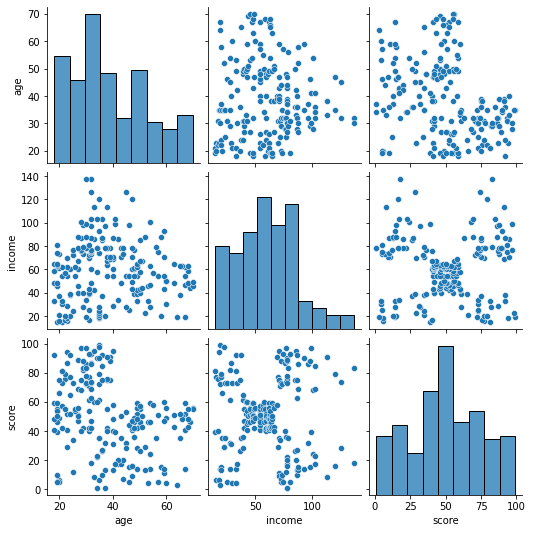

In [82]:
#Histogram of specific features in dataset
sns.pairplot(df[['age','income','score']])

In [83]:
#Importing clustering library 
import sklearn.cluster as cluster
#creat an object and define the cluster size
kmc=cluster.KMeans(n_clusters=5)
#Train the model 
kmc=kmc.fit(df[['score','income']])
#Determine the centers of the clusters
kmc.cluster_centers_

array([[49.51851852, 55.2962963 ],
       [79.36363636, 25.72727273],
       [82.12820513, 86.53846154],
       [17.11428571, 88.2       ],
       [20.91304348, 26.30434783]])

In [84]:
#Show the persons assigned to specific cluster e.g. income 
df['income_clusters']=kmc.labels_
df

,CustomerID,gender,age,income,score,income_clusters
0,1,Male,19,15,39,4
1,2,Male,21,15,81,1
2,3,Female,20,16,6,4
3,4,Female,23,16,77,1
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,2
196,197,Female,45,126,28,3
197,198,Male,32,126,74,2
198,199,Male,32,137,18,3


In [85]:
#How many persons are avaiable in specific cluster e.g. income 
df['income_clusters'].value_counts()

0    81
2    39
3    35
4    23
1    22
Name: income_clusters, dtype: int64

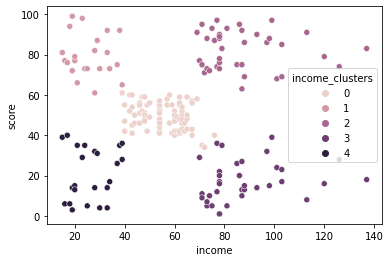

In [86]:
#Show the five clusters assigned in the income clusters 
sns.scatterplot(x='income',y='score',hue='income_clusters',data=df)

Show the same result for age cluster

In [87]:
#Creat an object and define cluster number 
kmc=cluster.KMeans(n_clusters=2)
#Train the model
kmc=kmc.fit(df[['age','score']])
#Determine the centers of clusters
kmc.cluster_centers_

array([[28.95294118, 73.62352941],
       [46.16521739, 32.88695652]])

In [88]:
#Show the persons assigned to specific cluster e.g. age
df['age_clusters']=kmc.labels_
df

,CustomerID,gender,age,income,score,income_clusters,age_clusters
0,1,Male,19,15,39,4,1
1,2,Male,21,15,81,1,0
2,3,Female,20,16,6,4,1
3,4,Female,23,16,77,1,0
4,5,Female,31,17,40,4,1
...,...,...,...,...,...,...,...
195,196,Female,35,120,79,2,0
196,197,Female,45,126,28,3,1
197,198,Male,32,126,74,2,0
198,199,Male,32,137,18,3,1


In [89]:
#How many persons are avaiable in specific cluster e.g. age
df['age_clusters'].value_counts()

1    115
0     85
Name: age_clusters, dtype: int64

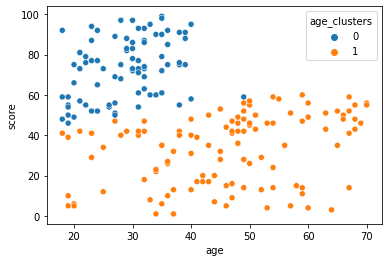

In [90]:
#Show the two clusters assigned in the age clusters 
sns.scatterplot(x='age',y='score',hue='age_clusters',data=df)

**Elbow Method Implementation**

In [91]:
#Elbow Method 
#Import clustering library
from sklearn.cluster import KMeans
K_range=range(1,12) #Define a variable for the range of k and assign 
wcss= [] #Define a array, where the wcss value will be placed after generation
for k in K_range:
  km = KMeans (n_clusters= k) #km is object
  km.fit(df[['income','score']])
  wcss.append(km.inertia_) #Add the value in the wcss array

In [92]:
#Show the WCSS value
wcss

[269981.28,
 181363.59595959593,
 106348.37306211122,
 73679.78903948836,
 44448.4554479337,
 37455.98455516028,
 30241.34361793658,
 25018.781613414067,
 21809.92756261518,
 20146.819163174678,
 17962.01797254328]

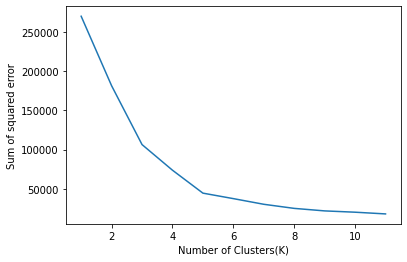

In [93]:
#Plot the WCSS versus the value of K
plt.xlabel('Number of Clusters(K)')
plt.ylabel('Sum of squared error')
plt.plot(K_range,wcss)